# Lumbar spine classification of MRI slices
## Dataset


In [1]:
import numpy as np
from PIL import Image
import os 
from collections import Counter
import matplotlib.pyplot as plt
import random
import numpy as np
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
from PIL import Image
import copy
import time
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import f1_score, accuracy_score

In [2]:
os.chdir("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data")
print(os.getcwd())

/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data


In [3]:
import os
import re
import pandas as pd

data_dir = "./data-classification"

def extract_num(fname):
    m = re.search(r"image_(\d+)\.jpg$", fname)
    return int(m.group(1)) if m else None

records = []

for split in ["train", "test"]:
    for cls in os.listdir(os.path.join(data_dir, split)):
        cls_path = os.path.join(data_dir, split, cls)
        if not os.path.isdir(cls_path):
            continue
        
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(".jpg")]
        files = sorted(files, key=extract_num)  # natural numeric order
        
        for f in files:
            records.append({
                "path": os.path.join(cls_path, f),
                "label": cls,
                "orig_split": split,
                "filename": f,
                "num_id": extract_num(f)
            })

df = pd.DataFrame(records)
df.head()

,path,label,orig_split,filename,num_id
0,./data-classification/train/No Stenosis/image_...,No Stenosis,train,image_27.jpg,27
1,./data-classification/train/No Stenosis/image_...,No Stenosis,train,image_29.jpg,29
2,./data-classification/train/No Stenosis/image_...,No Stenosis,train,image_30.jpg,30
3,./data-classification/train/No Stenosis/image_...,No Stenosis,train,image_31.jpg,31
4,./data-classification/train/No Stenosis/image_...,No Stenosis,train,image_32.jpg,32


In [4]:
def count_images(data_dir):
    class_counts = {}
    
    for split in ["train", "test"]:
        split_path = os.path.join(data_dir, split)
        class_counts[split] = {}
        
        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                class_counts[split][cls] = len(os.listdir(cls_path))
    
    return class_counts

data_dir = "./data-classification"
counts = count_images(data_dir)

counts

{'train': {'No Stenosis': 3153, 'Thecal Sac': 4733, 'Herniated Disc': 3064},
 'test': {'No Stenosis': 1507, 'Thecal Sac': 13, 'Herniated Disc': 1218}}

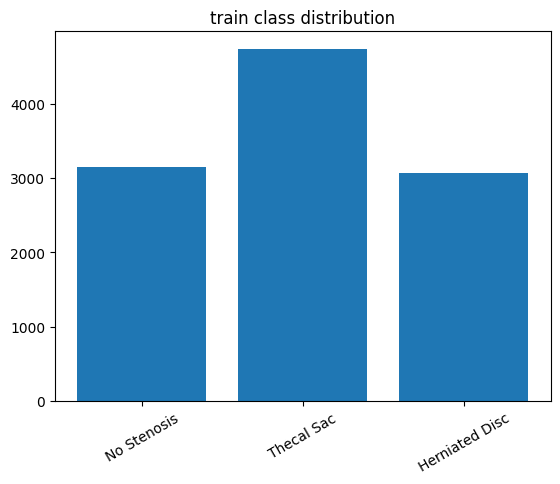

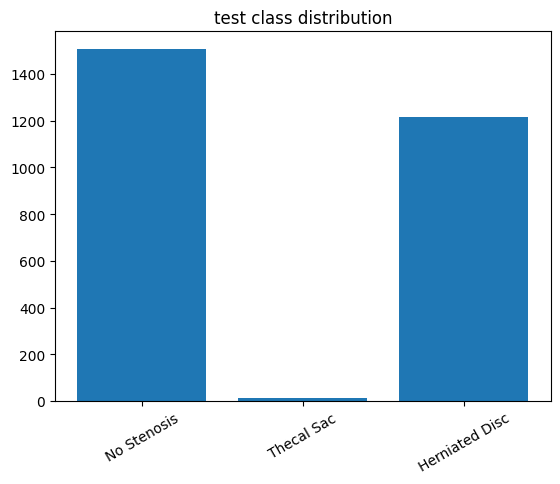

In [5]:
def plot_distribution(counts, split):
    classes = list(counts[split].keys())
    values = list(counts[split].values())
    
    plt.figure()
    plt.bar(classes, values)
    plt.title(f"{split} class distribution")
    plt.xticks(rotation=30)
    plt.show()

plot_distribution(counts, "train")
plot_distribution(counts, "test")

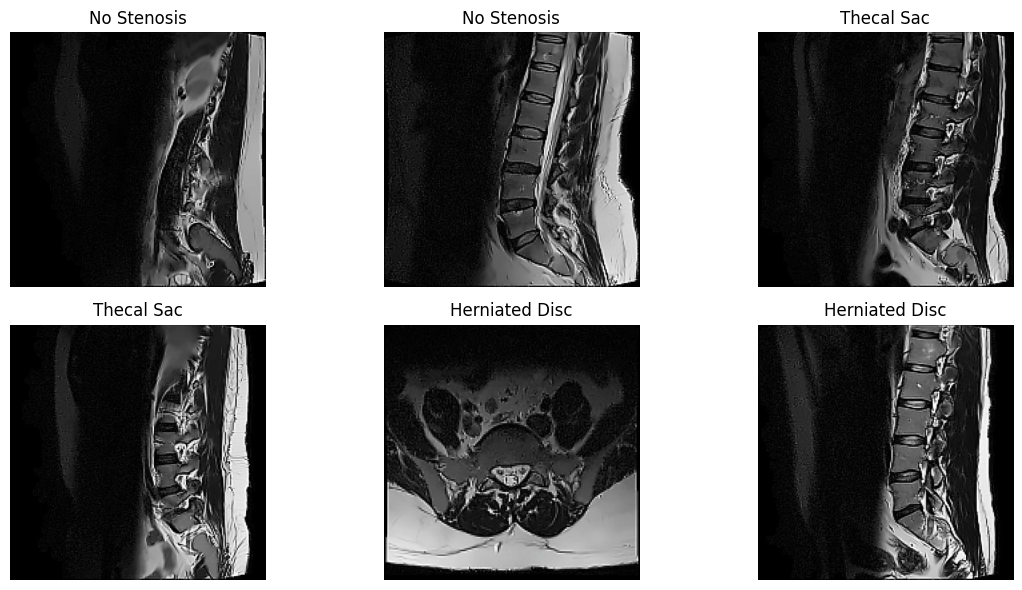

In [26]:
def show_samples(data_dir, split="train", num_samples=6):
    plt.figure(figsize=(12, 6))
    
    i = 1
    for cls in os.listdir(os.path.join(data_dir, split)):
        cls_path = os.path.join(data_dir, split, cls)
        images = os.listdir(cls_path)
        
        for _ in range(num_samples // 2):
            img_name = random.choice(images)
            img_path = os.path.join(cls_path, img_name)
            
            img = Image.open(img_path)
            
            plt.subplot(2, 3, i)
            plt.imshow(img, cmap="gray")
            plt.title(cls)
            plt.axis("off")
            i += 1
    
    plt.tight_layout()
    plt.show()

show_samples(data_dir)

In [8]:
# pick one sample image
sample_class = os.listdir(os.path.join(data_dir, "train"))[0]
sample_image = os.listdir(os.path.join(data_dir, "train", sample_class))[0]

img_path = os.path.join(data_dir, "train", sample_class, sample_image)

img = Image.open(img_path)
print(img.mode)
print(img.size)

img = np.array(Image.open(img_path))

print("Channels equal:",
      np.all(img[:,:,0] == img[:,:,1]) and np.all(img[:,:,1] == img[:,:,2]))

RGB
(400, 400)
Channels equal: True


In [9]:
def compute_mean_std(data_dir, n=500):

    pixels = []
    
    for _ in range(n):
        path = img_path
        img = np.array(Image.open(path)) / 255.0
        pixels.append(img)
    
    pixels = np.concatenate([p.flatten() for p in pixels])
    
    print("Mean:", pixels.mean())
    print("Std:", pixels.std())

compute_mean_std(data_dir)

Mean: 0.1669754166666658
Std: 0.23722958871252095


In [10]:
mean = [0.167, 0.167, 0.167]
std  = [0.237, 0.237, 0.237]